# Interpreting Clusters


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

%matplotlib inline

```{contents}
:local:
:depth: 2
```


This section shows how to interpret a k-means result after the model has been fit. The technical output is only the starting point. The analyst still has to choose a reasonable number of clusters, describe each cluster, and decide whether the grouping supports the business question.

In [2]:
# Create Data
X, original_labels = make_blobs(
    n_samples=200,
    n_features=2,
    centers=4,
    cluster_std=1.8,
    random_state=101,
)

## Choosing k

K-means needs the number of clusters up front. Two common heuristics are the elbow method and the silhouette score. These tools help compare choices, but they do not remove judgment. A technically neat value of `k` still needs a practical interpretation.

## Elbow Check

The **elbow method** fits k-means for several values of `k` and records the model's inertia, which is the within-cluster sum of squares. Lower inertia is better, but it always improves as `k` increases. The useful question is where the improvement starts to flatten.

In [3]:
inertias = []
k_values = range(2, 8)

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=101)
    model.fit(X)
    inertias.append(model.inertia_)

elbow_df = pd.DataFrame({"k": list(k_values), "inertia": inertias})
elbow_df

,k,inertia
0,2,3799.162910
1,3,2288.056530
2,4,1318.403573
3,5,1137.662691
4,6,999.712283
5,7,856.034015


Text(0, 0.5, 'Inertia')

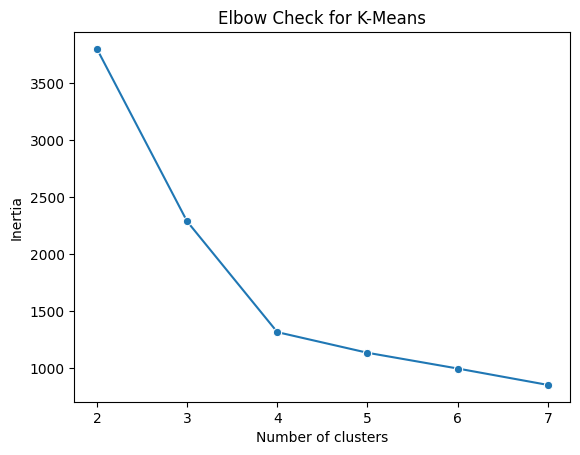

In [4]:
sns.lineplot(data=elbow_df, x="k", y="inertia", marker="o")
plt.title("Elbow Check for K-Means")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")

## Silhouette Check

The **silhouette score** compares how close each point is to its own cluster relative to nearby clusters. Values closer to 1 suggest tighter, better-separated clusters. Values near 0 suggest overlap, and negative values suggest points may be assigned to the wrong cluster.

In [5]:
silhouette_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=101)
    labels = model.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

silhouette_df = pd.DataFrame({"k": list(k_values), "silhouette": silhouette_scores})
silhouette_df

,k,silhouette
0,2,0.649084
1,3,0.503945
2,4,0.551977
3,5,0.485028
4,6,0.388940
5,7,0.371006


Text(0, 0.5, 'Silhouette score')

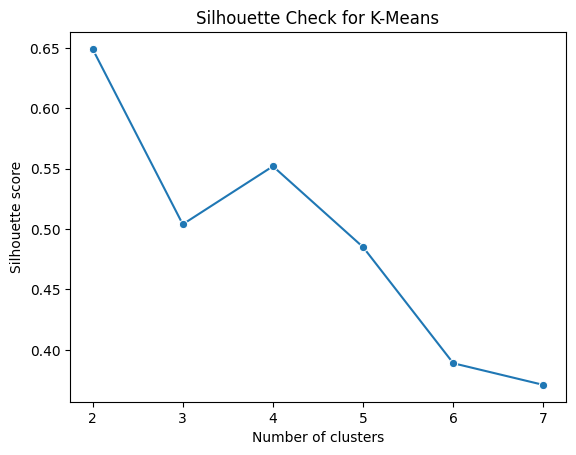

In [6]:
sns.lineplot(data=silhouette_df, x="k", y="silhouette", marker="o")
plt.title("Silhouette Check for K-Means")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")

## Describing Clusters

After choosing `k`, summarize each cluster in the units that matter for the decision. In a customer example, that might mean average order value, purchase frequency, tenure, and churn rate. In an operations example, it might mean processing time, defect rate, and order size.

In [7]:
final_model = KMeans(n_clusters=4, n_init=10, random_state=101)
cluster_labels = final_model.fit_predict(X)

cluster_df = pd.DataFrame(X, columns=["feature_1", "feature_2"])
cluster_df["cluster"] = cluster_labels
cluster_df.groupby("cluster").mean().round(2)

,feature_1,feature_2
cluster,,
0,-9.47,-6.56
1,-0.01,2.13
2,3.72,7.01
3,-4.14,7.95


## Practical Interpretation

Cluster labels are useful only when they support an interpretable decision. The final step is to describe the groups in business language and decide whether the segments suggest different actions.

The colors in a cluster plot are arbitrary. Cluster `0` in one model is not guaranteed to match cluster `0` in another model, even when the same data are used.

Text(0.5, 1.0, 'Final K-Means Clusters')

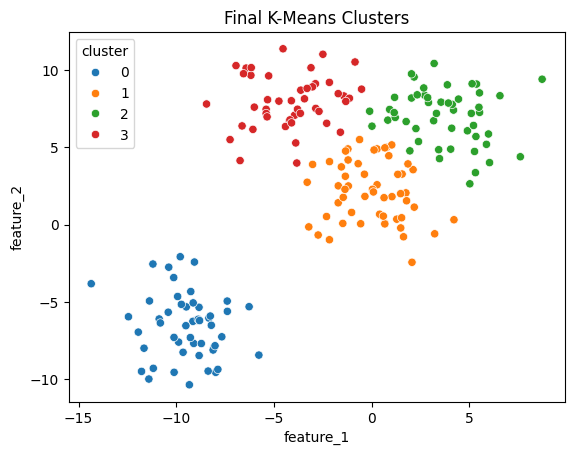

In [8]:
sns.scatterplot(data=cluster_df, x="feature_1", y="feature_2", hue="cluster", palette="tab10")
plt.title("Final K-Means Clusters")

## Practical Tips

- Scale features before clustering when units differ.
- Run multiple initializations with `n_init` to avoid poor local minima.
- Use `random_state` for reproducible examples.
- Treat cluster labels as arbitrary identifiers, not ranked categories.
- Validate clusters with domain knowledge before using them for decisions.


## Section Practice

Use this short exercise to check the main workflow from this section.


In [9]:
### Exercise: Practice Interpreting Clusters
# A model produced the predictions and actual values below.
# Calculate each error as actual minus predicted. Then print the mean absolute error.
predicted = [98, 105, 110, 120]
actual = [100, 102, 114, 119]
### Your code starts here




### Your code ends here


In [10]:
### Solution
predicted = [98, 105, 110, 120]
actual = [100, 102, 114, 119]
errors = [a - p for a, p in zip(actual, predicted)]
mean_absolute_error = sum(abs(error) for error in errors) / len(errors)
print(errors)
print(mean_absolute_error)


[2, -3, 4, -1]
2.5


In [ ]:
### Exercise: Section Practice 1
# book-rule-sparse-practice
# A manager wants a short check on the chapter section named below.
# Create a list named steps with three actions: identify decision, choose metric, explain result.
# Print exactly these three lines, using the existing section_focus value:
# Section: Choosing k
# Steps: 3
# First step: identify decision
section_focus = 'Choosing k'

### Your code starts here.

### Your code ends here.


In [ ]:
section_focus = 'Choosing k'
steps = ["identify decision", "choose metric", "explain result"]
print("Section:", section_focus)
print("Steps:", len(steps))
print("First step:", steps[0])


Section: Choosing k
Steps: 3
First step: identify decision


In [ ]:
### Exercise: Section Practice 2
# book-rule-sparse-practice
# The chapter uses the section headings to organize related ideas.
# Store the three provided terms in a list named representative_terms.
# Print exactly these two lines:
# Terms: Choosing, Elbow, Check
# Term count: 3
provided_terms = ['Choosing', 'Elbow', 'Check']

### Your code starts here.

### Your code ends here.


In [ ]:
representative_terms = ['Choosing', 'Elbow', 'Check']
print("Terms:", ", ".join(representative_terms))
print("Term count:", len(representative_terms))


Terms: Choosing, Elbow, Check
Term count: 3
